In [ ]:
!pip install yomitoku nest_asyncio

In [ ]:
import cv2
import nest_asyncio
from pathlib import Path
from datetime import datetime
from yomitoku import DocumentAnalyzer
from yomitoku.data.functions import load_pdf

# Jupyter Notebookでasyncioのネストを許可
nest_asyncio.apply()

PATH_IMGE = "data/sample.pdf"
analyzer = DocumentAnalyzer(visualize=True, device="cuda")

output_dir = Path(f"./output/{datetime.now().strftime('%Y%m%d_%H%M%S')})")
output_dir.mkdir(parents=True, exist_ok=True)

# PDFファイルを読み込み
imgs = load_pdf(PATH_IMGE)
for i, img in enumerate(imgs):
    results, ocr_vis, layout_vis = analyzer(img)
    # HTML形式で解析結果をエクスポート
    results.to_html(str(output_dir / f"output_{i}.html"), img=img)
    # 可視化画像を保存
    cv2.imwrite(str(output_dir / f"output_ocr_{i}.jpg"), ocr_vis)
    cv2.imwrite(str(output_dir / f"output_layout_{i}.jpg"), layout_vis)

In [ ]:
import cv2
import time
import nest_asyncio
from pathlib import Path
from datetime import datetime
from yomitoku import OCR
from yomitoku.data.functions import load_pdf

# Jupyter Notebookでasyncioのネストを許可
nest_asyncio.apply()

ocr = OCR(visualize=True, device="cuda")
imgs = load_pdf("data/sample.pdf")

output_dir = Path(f"./output/{datetime.now().strftime('%Y%m%d_%H%M%S')})")
output_dir.mkdir(parents=True, exist_ok=True)

start = time.time()
for i, img in enumerate(imgs):

    results, ocr_vis = ocr(img)
    # JSON形式で解析結果をエクスポート
    results.to_json(str(output_dir / f"output_{i}.json"))
    cv2.imwrite(str(output_dir / f"output_ocr_{i}.jpg"), ocr_vis)

2025-11-12 00:23:31,984 - yomitoku.data.functions - WARNING - 
            The image size is small, which may result in reduced OCR accuracy. 
            The process will continue, but it is recommended to input images with a minimum size of 720 pixels on the shorter side.
            


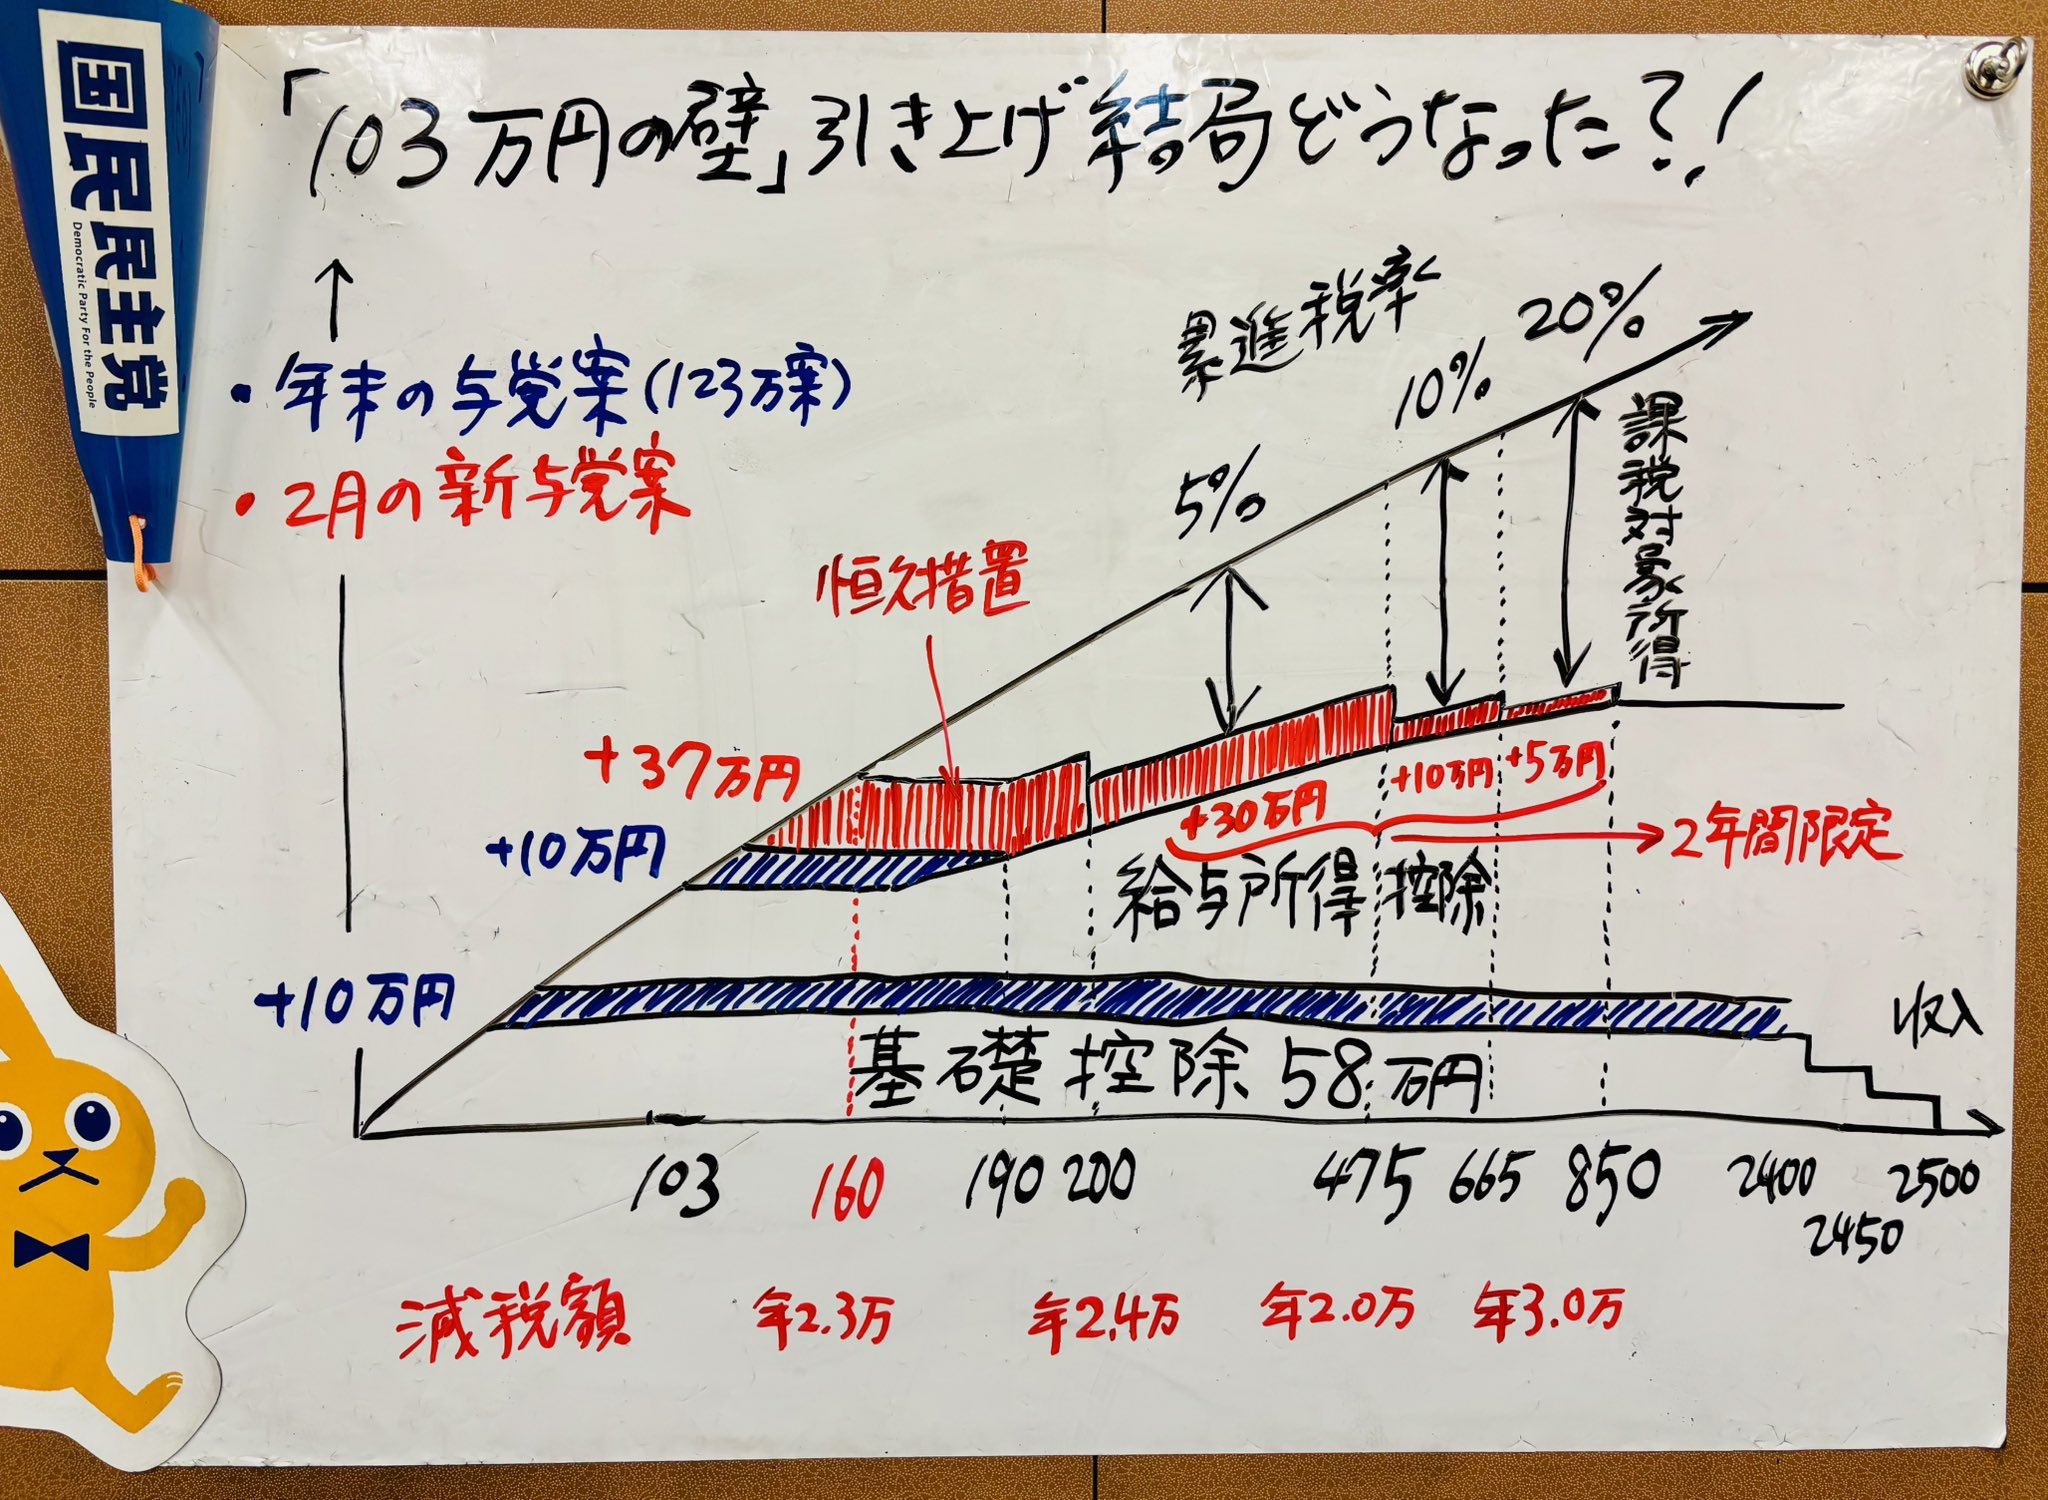

CPU times: total: 2.16 s
Wall time: 760 ms


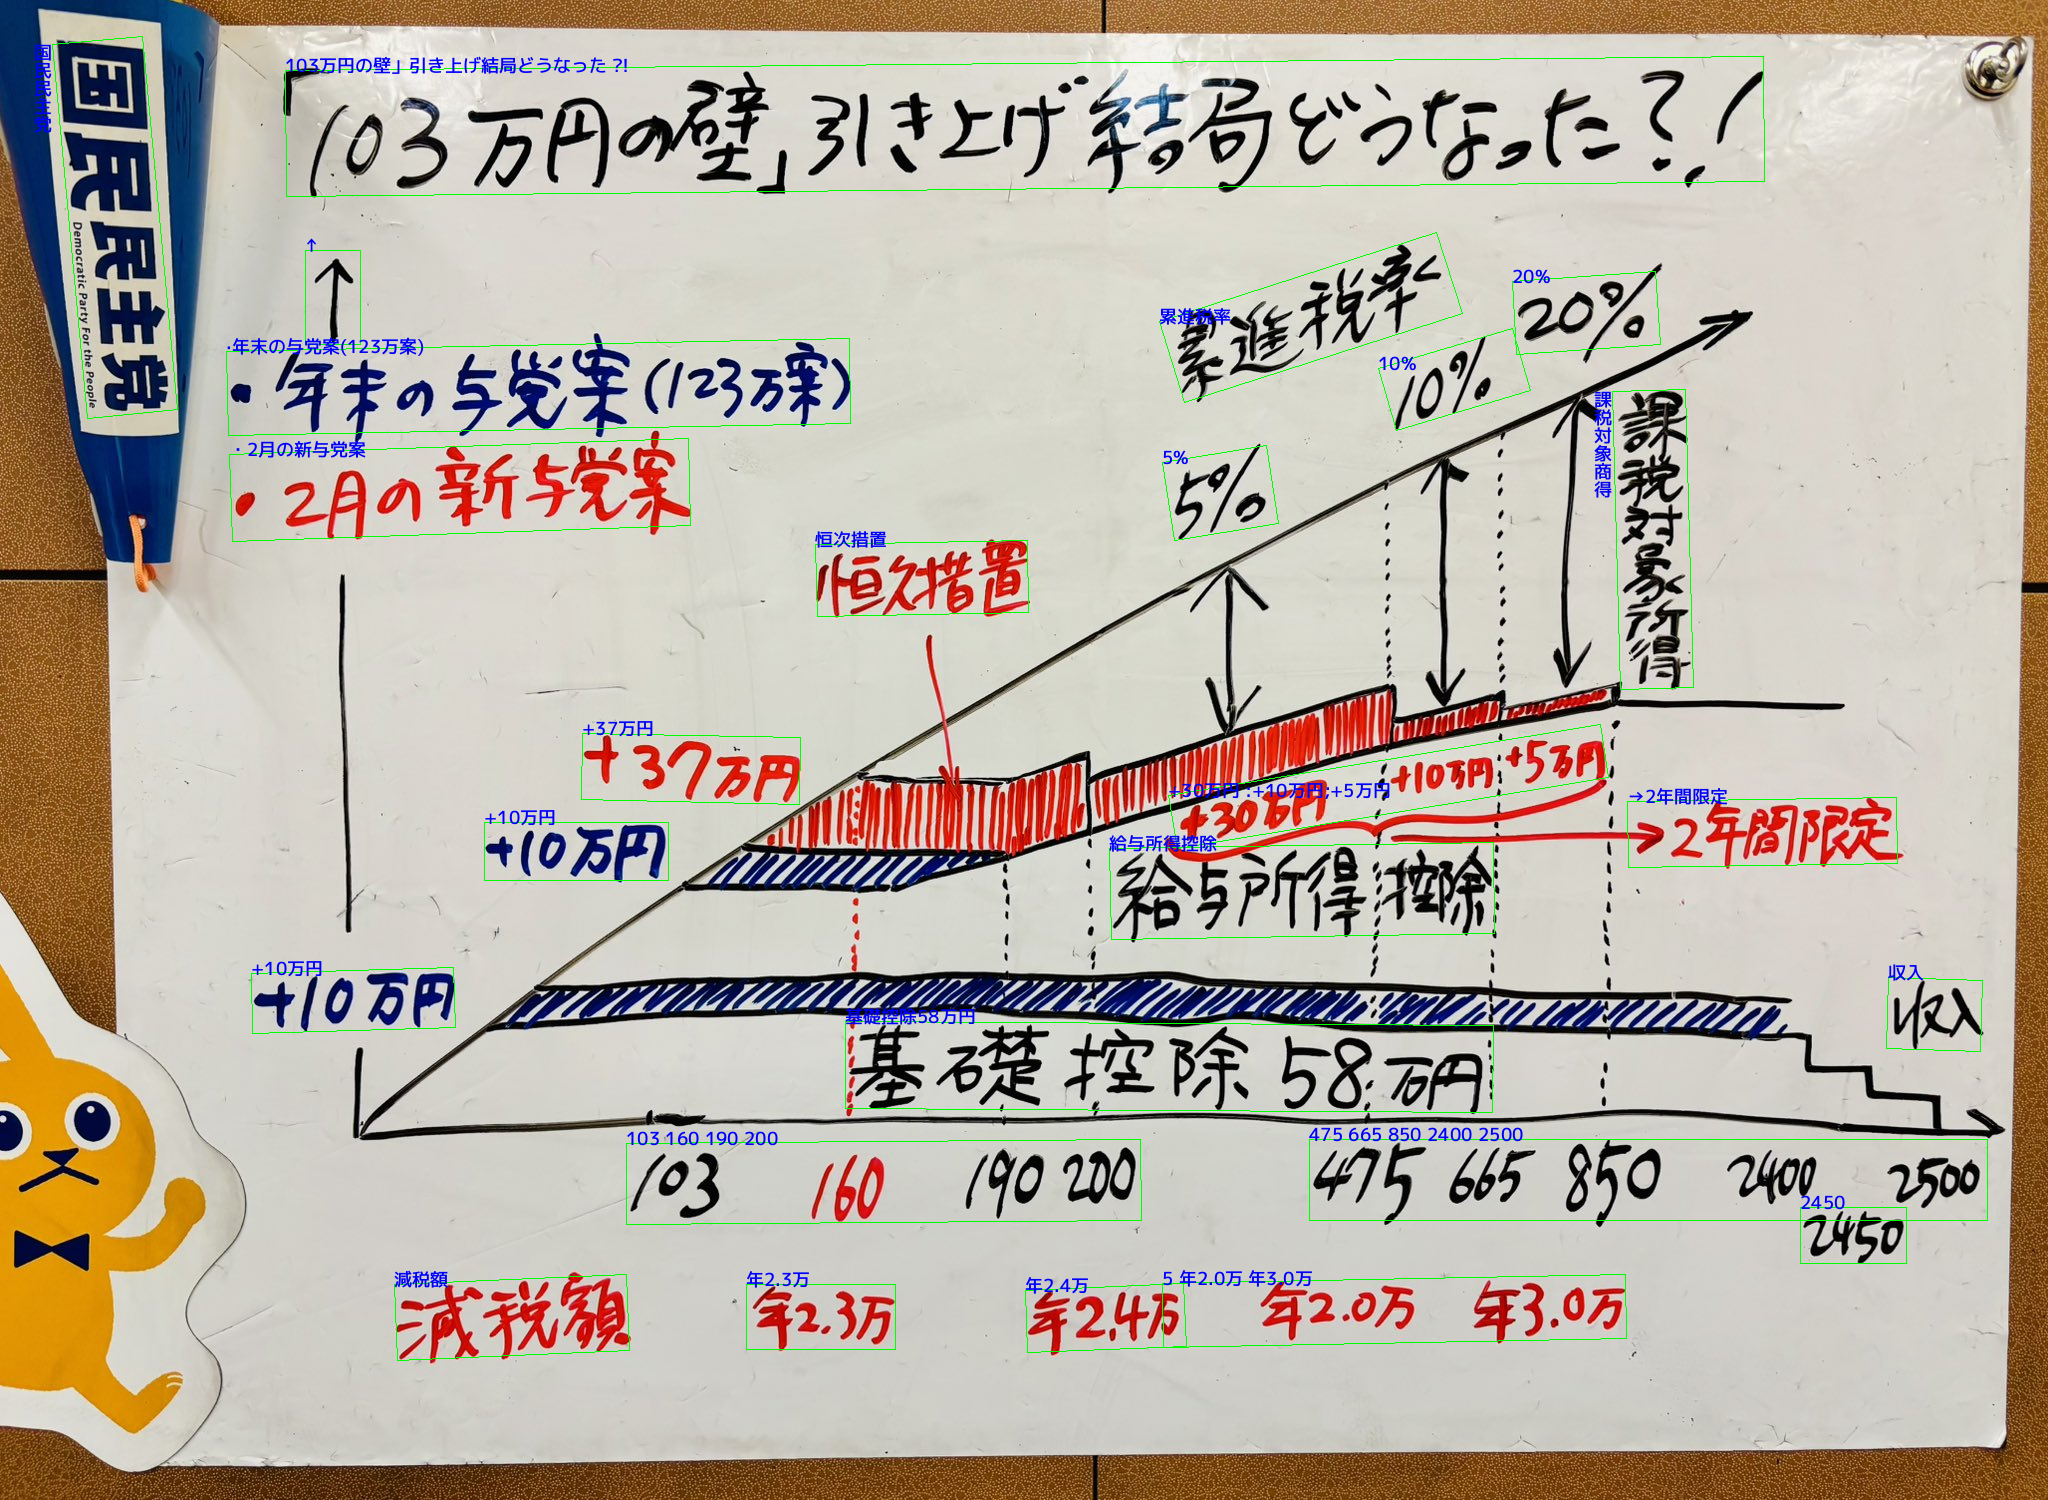

In [ ]:
import cv2
import nest_asyncio
from PIL import Image
from IPython.display import display
from pathlib import Path
from datetime import datetime
from yomitoku import OCR
from yomitoku.data.functions import load_image

# yomitokuのlogger出力を無効化
import logging
logging.getLogger("yomitoku.base").setLevel(logging.CRITICAL)

# Jupyter Notebookでasyncioのネストを許可
nest_asyncio.apply()

ocr = OCR(visualize=True, device="cuda")

output_dir = Path(f"./output/{datetime.now().strftime('%Y%m%d_%H%M%S')})")
output_dir.mkdir(parents=True, exist_ok=True)

img = load_image("data/gallery5.jpg")
img = load_image("data/gallery7.jpeg")
display(Image.fromarray(img[0][:,:,::-1]))

results, ocr_vis = ocr(img[0])
results.to_json(str(output_dir / "output.json"))
cv2.imwrite(str(output_dir / "output_ocr.jpg"), ocr_vis)

display(Image.fromarray(ocr_vis[:,:,::-1]))